In [3]:
# ===================== ALL-IN-ONE: 3D simplex (tetrahedra) for Multiwell Function =====================
# Requirements: pyomo, ipopt (NLP), numpy, scipy, plotly, tqdm
# -----------------------------------------------------------------------------------------

import numpy as np
import itertools as it
from tqdm import tqdm
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
from scipy.spatial import Delaunay
import plotly.graph_objects as go
import matplotlib.pyplot as plt


# ------------------------- Config knobs -------------------------
MIN_DIST   = 1e-8     # 去重阈值
ACTIVE_TOL = 1e-8     # active 判定容差
MS_AGG     = "sum"    # 单形 ms 聚合：'sum' 或 'mean'

# ------------------------- Multiwell function (2~3 minima) -------------------------
# 你可以调这些参数让极小点更分明/更多或更少
MW_PARAMS_1 = {
    "beta": 0.18,
    "c":    np.array([5.0, 5.0, 5.0], dtype=float),
    # wells: each is (mu (3,), a, sigma)
    "wells": [
        (np.array([3.0, 4.0, 6.0]), 3.2, 1.2),
        (np.array([7.0, 6.0, 4.0]), 3.0, 1.3),
        # 第三个井：想要 2 个极小点就注释掉这一行
        (np.array([6.5, 3.2, 7.5]), 2.6, 1.1),
    ]
}
MW_PARAMS = {
    "beta": 0.18,
    "c": np.array([5.0, 5.0, 5.0]),
    "wells": [
        (np.array([3.5, 4.0, 6.5]), 3.00, 0.8),
        (np.array([6.5, 6.0, 3.5]), 3.00+1e-4, 0.8),
    ]
}


def f_multiwell_numpy(xyz, params=MW_PARAMS):
    x = np.asarray(xyz, dtype=float)
    beta = params["beta"]; c = params["c"]; wells = params["wells"]
    base = beta * np.sum((x - c)**2)
    dips = 0.0
    for mu, a, sig in wells:
        r2 = float(np.sum((x - mu)**2))
        dips += a * np.exp(- r2 / (2.0 * sig**2))
    return base - dips

# ---------- helper: 距离去重 ----------
def dedup_points(points, existing, tol=1e-8):
    """按欧氏距离去重；existing 会先并入去重基准集合"""
    uniq = []
    base = list(existing)
    for p in points:
        if not any(np.linalg.norm(np.asarray(p) - np.asarray(q)) < tol for q in base):
            uniq.append(tuple(map(float, p)))
            base.append(p)
    return uniq

# ---------- helper: 在一个四面体上做“加 ms 后的顶点值”与全局 UB 的等值切边 ----------
def ub_isocuts_on_tetra(verts, fverts_sum, ms_total, UB_global, tol=1e-12):
    """
    verts: 4 个顶点坐标 [(x,y,z)*4]
    fverts_sum: 不同场景求和后的 4 个顶点 f 值（你的 per_tet['fverts_sum']）
    ms_total: 该四面体的 ms 聚合（per_tet['ms']）
    UB_global: 当前全局 UB（不加 ms 的）
    返回：所有“g_j = fverts_sum[j] + ms_total” 与 UB_global 在边上相交的切点列表
    """
    g = np.array([float(v) + float(ms_total) for v in fverts_sum], dtype=float)
    V = np.array(verts, dtype=float)  # (4,3)

    edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
    cuts = []
    for a, b in edges:
        ga, gb = g[a], g[b]
        denom = (gb - ga)
        # 一上一下才会切；排除几乎平的情况
        if (ga - UB_global) * (gb - UB_global) < -tol and abs(denom) > tol:
            t = (UB_global - ga) / denom  # 线性插值参数
            if 0.0 <= t <= 1.0:
                p = (1 - t) * V[a] + t * V[b]
                cuts.append(tuple(map(float, p)))
        # 边界情形：某顶点几乎恰等于 UB_global（可选：也收录）
        elif abs(ga - UB_global) <= tol:
            cuts.append(tuple(map(float, V[a])))
        elif abs(gb - UB_global) <= tol:
            cuts.append(tuple(map(float, V[b])))

    # 边上可能产生多个同点，做一次本地去重
    out = []
    for p in cuts:
        if not any(np.linalg.norm(np.asarray(p) - np.asarray(q)) < 1e-12 for q in out):
            out.append(p)
    return out

# ------------------------- Build the Pyomo model of f(x,y,z) -------------------------
def build_multiwell_model(bounds_xyz=(0.0, 10.0), params=MW_PARAMS):
    """ 单场景模型：只有 x,y,z 三个变量和一个光滑目标 obj_expr=f(x,y,z) """
    lo, hi = bounds_xyz
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(lo, hi))
    m.y = pyo.Var(bounds=(lo, hi))
    m.z = pyo.Var(bounds=(lo, hi))

    beta = params["beta"]
    cx, cy, cz = params["c"].tolist()

    # 构造 f(x,y,z) 的表达式
    # base bowl
    base = beta*((m.x - cx)**2 + (m.y - cy)**2 + (m.z - cz)**2)

    # sum of Gaussian wells
    dips = 0
    for (mu, a, sig) in params["wells"]:
        mx, my, mz = mu.tolist()
        r2 = (m.x - mx)**2 + (m.y - my)**2 + (m.z - mz)**2
        # 用 Pyomo 的 exp
        dips += a * pyo.exp(- r2 / (2.0 * (sig**2)))

    m.obj_expr = pyo.Expression(expr = base - dips)
    return m, [m.x, m.y, m.z]

def build_models(num_scenarios=1, bounds_xyz=(0.0,10.0), params=MW_PARAMS):
    """ 生成 num_scenarios 个“场景”副本（参数相同），以便沿用原有多场景接口/打印 """
    model_list, first_stg_vars_list = [], []
    for _ in range(num_scenarios):
        m, vars3 = build_multiwell_model(bounds_xyz=bounds_xyz, params=params)
        model_list.append(m)
        first_stg_vars_list.append(vars3)
    m_tmpl_list = [model_list[0], first_stg_vars_list[0]]
    T = None  # 保留接口占位
    return model_list, first_stg_vars_list, m_tmpl_list, T

# ------------------------- Basic utils -------------------------
def corners_from_var_bounds(vars_3):
    bnds = []
    for v in vars_3:
        lb, ub = v.lb, v.ub
        if lb is None or ub is None:
            raise ValueError(f"{v.name} 缺少上下界")
        bnds.append((float(lb), float(ub)))
    return [tuple(p) for p in it.product(*[(lo, hi) for (lo,hi) in bnds])]

def too_close(p, nodes, tol=MIN_DIST):
    return any(np.linalg.norm(np.asarray(p)-np.asarray(q)) < tol for q in nodes)

def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    """
    把 x,y,z 固定到给定值，直接数值计算 obj_expr；不调用 solver。
    这样就不会出现“模型没有自由变量”的 NL 接口报错。
    """
    # 固定变量
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(float(v))

    try:
        # 直接对 Pyomo 表达式求值
        val = float(pyo.value(model.obj_expr))
        return val
    finally:
        # 清理：解锁变量
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()


# ------------------------- Single tetra & scene: ms solve -------------------------
def ms_on_tetra_for_scene(model_tmpl, first_vars, solver, tet_vertices, fverts_scene):
    """
    在一个四面体上：
      ms = min_{lambda>=0, 1^T lambda=1} [ obj_expr(x(lambda)) - sum_j lambda_j f(v_j) ]
    x(lambda)=∑ λ_j * v_j， 这里一个“场景”就是一个相同的 f
    """
    m = model_tmpl.clone()

    # 取 x,y,z
    vx = m.find_component(first_vars[0].name)
    vy = m.find_component(first_vars[1].name)
    vz = m.find_component(first_vars[2].name)
    if any(v is None for v in (vx,vy,vz)):
        raise RuntimeError("克隆模型中找不到 x/y/z")

    # 重心变量
    m.lam = pyo.Var(range(4), domain=pyo.NonNegativeReals)
    m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(4)) == 1.0)

    tx = [float(tet_vertices[j][0]) for j in range(4)]
    ty = [float(tet_vertices[j][1]) for j in range(4)]
    tz = [float(tet_vertices[j][2]) for j in range(4)]
    m.link_x = pyo.Constraint(expr=vx == sum(m.lam[j]*tx[j] for j in range(4)))
    m.link_y = pyo.Constraint(expr=vy == sum(m.lam[j]*ty[j] for j in range(4)))
    m.link_z = pyo.Constraint(expr=vz == sum(m.lam[j]*tz[j] for j in range(4)))

    # As
    m.As = pyo.Var()
    m.As_def = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts_scene[j]) for j in range(4)))

    if hasattr(m, 'obj'): m.del_component('obj')
    m.obj = pyo.Objective(expr=m.obj_expr - m.As, sense=pyo.minimize)

    res = solver.solve(m, tee=False)
    ok = (res.solver.status == SolverStatus.ok) and \
         (res.solver.termination_condition in (TerminationCondition.optimal,
                                               TerminationCondition.locallyOptimal))
    if not ok:
        return float('inf'), None, None

    ms_val = float(pyo.value(m.obj))
    lam_star = np.array([pyo.value(m.lam[j]) for j in range(4)], dtype=float)
    new_pt = np.dot(lam_star, np.array(tet_vertices, dtype=float))
    return ms_val, lam_star, tuple(map(float, new_pt))

# ------------------------- Evaluate all tetrahedra -------------------------
def evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver):
    """
    nodes           : 当前节点列表（3D 点）
    scen_values     : 形状 S×len(nodes)，每个“场景”在每个节点上的真实值
    返回 tri, per_tet； per_tet 每项含：
      'simplex_index','vert_idx','verts','fverts_sum','ms_per_scene','ms','LB','UB','x_ms_best_scene','best_scene'
    """
    pts = np.asarray(nodes, dtype=float)
    if len(pts) < 4:
        return None, []
    tri = Delaunay(pts)  # simplices: (M,4)
    S = len(model_list)

    per_tet = []
    for k, simp in enumerate(tri.simplices):
        idxs = list(map(int, simp))
        verts = [tuple(pts[i]) for i in idxs]
        # 各场景四顶点值（这里各场景相同）
        fverts_per_scene = [[scen_values[ω][i] for i in idxs] for ω in range(S)]
        # “总 f” 顶点
        fverts_sum = [sum(fverts_per_scene[ω][j] for ω in range(S)) for j in range(4)]

        ms_scene = []
        xms_scene = []
        for ω in range(S):
            ms_val, lam_star, new_pt = ms_on_tetra_for_scene(
                model_list[ω], first_vars_list[ω], solver, verts, fverts_per_scene[ω]
            )
            ms_scene.append(ms_val)
            xms_scene.append(new_pt)

        if MS_AGG == "sum":
            ms_total = float(np.sum(ms_scene))
        elif MS_AGG == "mean":
            ms_total = float(np.mean(ms_scene))
        else:
            raise ValueError("MS_AGG must be 'sum' or 'mean'")

        LB = float(np.min(fverts_sum) + ms_total)
        UB = float(np.max(fverts_sum) + ms_total)

        best_scene = int(np.argmin(ms_scene))
        x_ms_best = xms_scene[best_scene]

        per_tet.append({
            "simplex_index": k,
            "vert_idx": idxs,
            "verts": verts,
            "fverts_sum": fverts_sum,
            "ms_per_scene": ms_scene,
            "ms": ms_total,
            "LB": LB,
            "UB": UB,
            "x_ms_best_scene": x_ms_best,
            "best_scene": best_scene,
        })

    return tri, per_tet

# ------------------------- Pretty print (保留你原来的风格/颜色) -------------------------
def print_tetra_table(per_tet, active_mask, purple_set=None, prec=6):
    purple_set = set() if purple_set is None else set(purple_set)
    per_tet = sorted(per_tet, key=lambda r: r["simplex_index"])
    tet_ids = [r["simplex_index"] for r in per_tet]
    active_set = {tid for tid in tet_ids if active_mask.get(tid, False)}

    def _mark(tid):
        s = f"T{tid}"
        flags = []
        if tid in active_set:  flags.append("*")
        if tid in purple_set:  flags.append("^")
        return s + ("".join(flags) if flags else "")

    header = ["row\\simp"] + [_mark(tid) for tid in tet_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.{prec}f}" for r in per_tet],
        ["LB"] + [f"{r['LB']:.{prec}f}" for r in per_tet],
        ["ms"] + [f"{r['ms']:.3e}"       for r in per_tet],
    ]

    table = [header] + rows
    colw = [max(len(str(row[c])) for row in table) + 2 for c in range(len(header))]

    RED, PURPLE, RESET = "\033[31m", "\033[35m", "\033[0m"
    def colorize(col_idx, s):
        if col_idx == 0:
            return s
        tid = tet_ids[col_idx-1]
        if tid in purple_set:
            return f"{PURPLE}{s}{RESET}"
        elif tid in active_set:
            return f"{RED}{s}{RESET}"
        return s

    print("\n== Per-tetra summary ==")
    print("".join(colorize(c, str(header[c]).ljust(colw[c])) for c in range(len(header))))
    print("-"*sum(colw))
    for r in rows:
        line = []
        for c in range(len(header)):
            cell = str(r[c])
            pad  = cell.ljust(colw[c]) if c==0 else cell.rjust(colw[c])
            line.append(colorize(c, pad))
        print("".join(line))
    print("(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)\n")

def print_per_scenario_ms(per_tet, max_scenarios_to_print=10, prec=3):
    per_tet = sorted(per_tet, key=lambda r: r["simplex_index"])
    if not per_tet or "ms_per_scene" not in per_tet[0]:
        return
    S = len(per_tet[0]["ms_per_scene"])
    show = min(S, max_scenarios_to_print)
    head = "simp | " + " ".join([f"s{j}".rjust(10) for j in range(show)])
    print("== Per-tetra per-scenario ms (showing first", show, "of", S, "scenes) ==")
    print(head)
    print("-"*len(head))
    for r in per_tet:
        arr = r["ms_per_scene"][:show]
        sline = " ".join([f"{v:.{prec}e}".rjust(10) for v in arr])
        print(f"{r['simplex_index']:>4d} | {sline}")
    if show < S:
        print(f"... ({S-show} scenes omitted)")
    print()

# ------------------------- Plotly visualization -------------------------
def plot_iteration_plotly(iter_id, nodes, tri, active_mask, ub_node, next_node, per_tet):
    fig = go.Figure()
    nodes = np.asarray(nodes, float)

    # ----------- 计算 active 节点集合 -----------
    active_nodes_idx = set()
    for r in per_tet:
        if active_mask.get(r["simplex_index"], False):
            active_nodes_idx.update(r["vert_idx"])
    inactive_nodes_idx = set(range(len(nodes))) - active_nodes_idx

    # ----------- 浅灰色点：非 active 节点 -----------
    if inactive_nodes_idx:
        pts = nodes[list(inactive_nodes_idx)]
        fig.add_trace(go.Scatter3d(
            x=pts[:,0], y=pts[:,1], z=pts[:,2],
            mode='markers',
            marker=dict(size=4, color='lightgray'),
            name='inactive nodes'
        ))

    # ----------- 黑色点：active 节点 -----------
    if active_nodes_idx:
        pts = nodes[list(active_nodes_idx)]
        fig.add_trace(go.Scatter3d(
            x=pts[:,0], y=pts[:,1], z=pts[:,2],
            mode='markers',
            marker=dict(size=4, color='black'),
            name='active nodes'
        ))

    # ----------- 红色点：真实极小点 -----------
    min_points = np.array([[3.5, 4.0, 6.5],
                           [6.5, 6.0, 3.5]])  # 你定义的两个极小点
    fig.add_trace(go.Scatter3d(
        x=min_points[:,0], y=min_points[:,1], z=min_points[:,2],
        mode='markers',
        marker=dict(size=7, color='red', symbol='diamond'),
        name='true minima'
    ))

    # ----------- 绿色点：当前最小 UB 节点 -----------
    if ub_node is not None:
        fig.add_trace(go.Scatter3d(
            x=[ub_node[0]], y=[ub_node[1]], z=[ub_node[2]],
            mode='markers',
            marker=dict(size=8, color='green', symbol='circle'),
            name='current min node'
        ))

    # ----------- 蓝色点：next node -----------
    if next_node is not None:
        fig.add_trace(go.Scatter3d(
            x=[next_node[0]], y=[next_node[1]], z=[next_node[2]],
            mode='markers',
            marker=dict(size=8, color='blue', symbol='circle'),
            name='next node'
        ))

    # active 单形：橙色半透明四面体 + 灰边
    if tri is not None:
        pts = tri.points
        legend_mesh_added = False
        legend_edge_added = False

        for r in per_tet:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            idxs = r["vert_idx"]
            verts = np.array([pts[i] for i in idxs], dtype=float)

            I = [0, 0, 0, 1]
            J = [1, 1, 2, 2]
            K = [2, 3, 3, 3]

            fig.add_trace(go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=I, j=J, k=K,
                color="#ff7043",
                opacity=0.35,
                showscale=False,
                name="active simplex",
                showlegend=(not legend_mesh_added)
            ))
            legend_mesh_added = True

            edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
            for (a, b) in edges:
                pa, pb = verts[a], verts[b]
                fig.add_trace(go.Scatter3d(
                    x=[pa[0], pb[0]],
                    y=[pa[1], pb[1]],
                    z=[pa[2], pb[2]],
                    mode='lines',
                    line=dict(width=2, color="gray"),
                    name="active edge",
                    showlegend=(not legend_edge_added)
                ))
            legend_edge_added = True

        # 质心 hover：展示每个单形的 LB/UB/ms
        cent_x, cent_y, cent_z, texts = [], [], [], []
        for r in per_tet:
            v = np.mean(np.asarray(r["verts"]), axis=0)
            ms_strs = [f"{val:.2e}" for val in r["ms_per_scene"][:8]]
            more = "" if len(r["ms_per_scene"]) <= 8 else f" (+{len(r['ms_per_scene'])-8} more)"
            txt = (f"simp={r['simplex_index']}<br>"
                   f"LB={r['LB']:.6f}<br>UB={r['UB']:.6f}<br>"
                   f"ms={r['ms']:.3e}<br>"
                   f"ms_per_scene: [{', '.join(ms_strs)}]")
            cent_x.append(v[0]); cent_y.append(v[1]); cent_z.append(v[2]); texts.append(txt)

        fig.add_trace(go.Scatter3d(
            x=cent_x, y=cent_y, z=cent_z,
            mode='markers',
            marker=dict(size=1, opacity=0.0),
            text=texts, hoverinfo="text",
            name="tetra info",
            showlegend=False
        ))

    fig.update_layout(
        title=f"Iteration {iter_id}",
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="z",
            aspectmode="cube"
        ),
        width=900,
        height=650,
        legend=dict(itemsizing="constant")
    )
    fig.show()

# ------------------------- Main iterative loop (保留打印&逻辑) -------------------------
def run_simplex_3d(model_list, first_vars_list, solver, target_nodes=30,
                   min_dist=MIN_DIST, active_tol=ACTIVE_TOL, verbose=True):
    S = len(model_list)
    # 角点初始化
    nodes = corners_from_var_bounds(first_vars_list[0])

    # 缓存 f_ω(node_i)
    scen_values = [[None]*len(nodes) for _ in range(S)]
    for i, node in enumerate(nodes):
        for ω in range(S):
            scen_values[ω][i] = evaluate_Q_at(model_list[ω], first_vars_list[ω], node, solver)

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []
    UB_node_hist = []

    it = 0
    while len(nodes) < target_nodes:
        # ---------- 全局 UB 与 UB 节点（不加 ms，总场景和） ----------
        f_sum_per_node = [sum(scen_values[ω][i] for ω in range(S)) for i in range(len(nodes))]
        ub_idx = int(np.argmin(f_sum_per_node))
        UB_global = float(f_sum_per_node[ub_idx])
        UB_node = tuple(nodes[ub_idx])

        # ---------- 四面体评估 ----------
        tri, per_tet = evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver)
        if tri is None or not per_tet:
            if verbose: print("Not enough nodes to make tetrahedra; stop.")
            break

        # ---------- active 单形：LB <= UB_global + tol ----------
        active_mask = {
            r["simplex_index"]:
                (r["LB"] <= UB_global + active_tol) and (UB_global <= r["UB"] + active_tol)
            for r in per_tet
        }
        active = [r for r in per_tet if active_mask[r["simplex_index"]]]

        # ---------- 全局 LB（维持你原先口径） ----------
        ms_adj = [r["ms"] for r in per_tet if ub_idx in r["vert_idx"]]
        if ms_adj:
            LB_global = UB_global + float(np.max(ms_adj))
        else:
            LB_global = float(np.min([r["LB"] for r in per_tet]))

        # 本轮 ms 指标（最小 ms）
        ms_iter = float(np.min([r["ms"] for r in per_tet]))

        LB_hist.append(LB_global); UB_hist.append(UB_global); ms_hist.append(ms_iter)
        node_count.append(len(nodes)); UB_node_hist.append(UB_node)

        # ---------- 打印表 ----------
        simp_with_min = [r["simplex_index"] for r in per_tet if ub_idx in r["vert_idx"]]
        purple_set = set(simp_with_min)
        if verbose:
            print(f"[Iter {it}] UB node {UB_node} is in simplices {sorted(simp_with_min)}")
            print_tetra_table(per_tet, active_mask, purple_set=purple_set)
            print_per_scenario_ms(per_tet, max_scenarios_to_print=10)
            print(f"[Global UB] = {UB_global:.6f}\n")

        # ---------- (A) 基于“加 ms 后顶点值”的 UB 等值切边，构造候选 ----------
        cut_points_all = []
        for r in active:
            cuts = ub_isocuts_on_tetra(
                verts=r["verts"],
                fverts_sum=r["fverts_sum"],
                ms_total=r["ms"],
                UB_global=UB_global,
            )
            if cuts:
                cut_points_all.extend(cuts)

        # 去重：先对比现有 nodes，再对候选内部去重
        cut_candidates = dedup_points(points=cut_points_all, existing=nodes, tol=min_dist)

        # ---------- 选新点：优先用等值切点，其次 ms 最小点，最后全体兜底 ----------
        new_node = None

        # (A1) 优先尝试 UB 等值切点
        if cut_candidates:
            for cand_pt in cut_candidates:
                if not too_close(cand_pt, nodes, tol=min_dist):
                    new_node = cand_pt
                    if verbose:
                        print(f"Chosen node (UB cut) {tuple(map(float, cand_pt))}")
                    break
            if new_node is None and verbose:
                print("All UB-cut candidates too close; fallback to ms-min scheme...")

        # (B) 回退：active 内按 ms 升序尝试 x_ms_best_scene
        if new_node is None:
            candidates = active if len(active) > 0 else per_tet
            candidates_sorted = sorted(candidates, key=lambda r: r["ms"])
            for cand in candidates_sorted:
                cand_pt = cand.get("x_ms_best_scene", None)
                if cand_pt is None:
                    continue
                if not too_close(cand_pt, nodes, tol=min_dist):
                    new_node = cand_pt
                    if verbose:
                        print(f"Chosen node {tuple(map(float, cand_pt))} "
                              f"with ms={cand['ms']:.3e} (simp {cand['simplex_index']})")
                    break
                else:
                    if verbose:
                        print(f"Skip candidate {tuple(map(float, cand_pt))} "
                              f"(simp {cand['simplex_index']}) because too close (< {min_dist:g}).")

        # (C) 仍不行：全体四面体兜底
        if new_node is None and len(active) > 0:
            if verbose:
                print("[fallback] All active candidates too close; try all simplices...")
            all_sorted = sorted(per_tet, key=lambda r: r["ms"])
            for cand in all_sorted:
                cand_pt = cand.get("x_ms_best_scene", None)
                if cand_pt is None:
                    continue
                if not too_close(cand_pt, nodes, tol=min_dist):
                    new_node = cand_pt
                    if verbose:
                        print(f"Chosen node {tuple(map(float, cand_pt))} "
                              f"with ms={cand['ms']:.3e} (simp {cand['simplex_index']}) [fallback-all]")
                    break
                else:
                    if verbose:
                        print(f"Skip (all) candidate {tuple(map(float, cand_pt))} "
                              f"(simp {cand['simplex_index']}) because too close (< {min_dist:g}).")

        if new_node is None:
            if verbose: print("New node too close for all candidates (or infeasible ms); stop.")
            break

        # ---------- 可视化 ----------
        plot_iteration_plotly(it, nodes, tri, active_mask, UB_node, new_node, per_tet)

        # ---------- 真实评估并加入节点 ----------
        new_vals = []
        for ω in range(S):
            val = evaluate_Q_at(model_list[ω], first_vars_list[ω], new_node, solver)
            new_vals.append(val)
        nodes.append(tuple(map(float, new_node)))
        for ω in range(S):
            scen_values[ω].append(new_vals[ω])

        it += 1

    return {
        "nodes": np.array(nodes, float),
        "LB_hist": LB_hist,
        "UB_hist": UB_hist,
        "ms_hist": ms_hist,
        "node_count": node_count,
        "UB_node_hist": UB_node_hist,
        "added_nodes": nodes[4:]  # 从角点之后加入的
    }


# ===================== MAIN =====================
RUN_QUICK_TEST = True  # True: 先用小规模验证

if RUN_QUICK_TEST:
    num_scenarios = 1
    target_nodes  = 20
else:
    num_scenarios = 3  # 需要多场景打印就>1；这里各场景相同参数
    target_nodes  = 30

bounds_xyz = (0.0, 10.0)

# build models
model_list, first_stg_vars_list, m_tmpl_list, T = build_models(
    num_scenarios=num_scenarios, bounds_xyz=bounds_xyz, params=MW_PARAMS
)

# Solver: 目标含 exp，需 NLP 求解器（推荐 ipopt）
solver = pyo.SolverFactory('ipopt')
# 可选参数：solver.options.update({...})

# run
hist = run_simplex_3d(
    model_list=model_list,
    first_vars_list=first_stg_vars_list,
    solver=solver,
    target_nodes=target_nodes,
    min_dist=MIN_DIST,
    active_tol=ACTIVE_TOL,
    verbose=True
)

print("\n==== Done ====")
print(f"Total nodes: {len(hist['nodes'])}")
print(f"Best UB: {min(hist['UB_hist']) if hist['UB_hist'] else None}")
print(f"Last LB: {hist['LB_hist'][-1] if hist['LB_hist'] else None}")
# ===========================================================================================

[Iter 0] UB node (0.0, 0.0, 10.0) is in simplices [1, 5]

== Per-tetra summary ==
row\simp  T0          T1^         T2          T3          T4          T5^         
----------------------------------------------------------------------------------
UB           -0.081668   -2.081351   -0.081668   -2.081449   -2.081449   -2.081351
LB           -0.081668   -2.081351   -0.081668   -2.081449   -2.081449   -2.081351
ms          -1.358e+01  -1.558e+01  -1.358e+01  -1.558e+01  -1.558e+01  -1.558e+01
(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)

== Per-tetra per-scenario ms (showing first 1 of 1 scenes) ==
simp |         s0
-----------------
   0 | -1.358e+01
   1 | -1.558e+01
   2 | -1.358e+01
   3 | -1.558e+01
   4 | -1.558e+01
   5 | -1.558e+01

[Global UB] = 13.500000

Chosen node (6.390705075694655, 5.9271545079707195, 3.609241551858659) with ms=-1.558e+01 (simp 4)


[Iter 1] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*^        T7*^        T8*^        T9*^        T10*^       T11*^       
----------------------------------------------------------------------------------------------------------------------------------------------------------
UB            4.499983    4.499983    4.499983    4.499983    4.500000    4.500000    4.499983    4.499983    4.500000    4.500000    4.499983    4.499983
LB          -11.081466  -11.081466  -11.081466  -11.081466  -11.081449  -11.081449  -11.081466  -11.081466  -11.081449  -11.081449  -11.081466  -11.081466
ms          -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00  -9.000e+00
(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)

== Per-tetra per-s

[Iter 2] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*^        T7*^        T8*^        T9*^        T10*^       T11*^       T12*        T13*        T14*        T15*        T16*        T17*        
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
UB            7.862981    7.862974    7.766412    7.706861    7.766394    7.706849    4.500000    4.500000    4.499983    4.499983    4.499983    4.499983    4.500000    4.500000    4.499983    4.499983    4.499983    4.499983
LB           -7.718469   -7.718475   -7.815037   -7.874588   -7.815056   -7.874600  -11.081449  -11.081449  -11.081466  -11.081466  -11.081466  -11.081466   -6.164

[Iter 3] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 3, 4, 5, 8, 9, 12, 13, 14, 15, 16, 17]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*         T7*         T8*^        T9*^        T10*        T11*        T12*^       T13*^       T14*^       T15*^       T16*^       T17*^       T18*        T19*        T20*        T21*        T22*        T23*        
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
UB            8.298387    8.298381    7.910671    7.910655    7.706861    8.340161    9.000000    7.766412    7.706849    8.340141    9.000000    7.766394    4.500000    4.500000    4.499983    4.499983    4.499983    4.499983    4.5000

[Iter 4] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 18, 19, 20, 21, 22, 23]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*^        T7*^        T8*         T9*         T10*^       T11*^       T12*        T13*        T14*        T15*        T16*        T17*        T18*^       T19*^       T20*^       T21*^       T22*^       T23*^       T24*        T25*        T26*        T27*        T28*        T29*        
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
UB            8.628912    8.628907    7.946167    7.946151    7.706861    7.706849  

...

[Iter 8] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 4, 7, 9, 10, 11, 14, 15, 18, 19, 22, 23, 26, 27, 30, 31, 34, 35, 36, 37, 38, 39]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*         T4*^        T5*         T6*         T7*^        T8*         T9*^        T10*^       T11*^       T12*        T13*        T14*^       T15*^       T16*        T17*        T18*^       T19*^       T20*        T21*        T22*^       T23*^       T24*        T25*        T26*^       T27*^       T28*        T29*        T30*^       T31*^       T32*        T33*        T34*^       T35*^       T36*^       T37*^       T38*^       T39*^       T40*        T41*        T42*        T43*        T44*        T45*        
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

[Iter 9] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 3, 4, 5, 10, 11, 14, 15, 18, 20, 22, 23, 26, 27, 30, 31, 34, 35, 38, 39, 40, 41, 42, 43]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*^        T6*         T7*         T8*         T9*         T10*^       T11*^       T12*        T13*        T14*^       T15*^       T16*        T17*        T18*^       T19*        T20*^       T21*        T22*^       T23*^       T24*        T25*        T26*^       T27*^       T28*        T29*        T30*^       T31*^       T32*        T33*        T34*^       T35*^       T36*        T37*        T38*^       T39*^       T40*^       T41*^       T42*^       T43*^       T44*        T45*        T46*        T47*        T48*        T49*        
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

[Iter 10] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 4, 5, 6, 7, 8, 9, 14, 15, 18, 19, 22, 24, 26, 27, 30, 31, 34, 35, 38, 39, 42, 43, 44, 45, 46, 47]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*         T3*         T4*^        T5*^        T6*^        T7*^        T8*^        T9*^        T10*        T11*        T12*        T13*        T14*^       T15*^       T16*        T17*        T18*^       T19*^       T20*        T21*        T22*^       T23*        T24*^       T25*        T26*^       T27*^       T28*        T29*        T30*^       T31*^       T32*        T33*        T34*^       T35*^       T36*        T37*        T38*^       T39*^       T40*        T41*        T42*^       T43*^       T44*^       T45*^       T46*^       T47*^       T48*        T49*        T50*        T51*        T52*        T53*        
----------------------------------------------------------------------------------------------------------------------

[Iter 11] UB node (6.390705075694655, 5.9271545079707195, 3.609241551858659) is in simplices [0, 1, 2, 3, 4, 9, 10, 13, 14, 17, 19, 20, 22, 24, 25, 29, 30, 33, 35, 36, 39, 40, 41, 42, 45, 46, 47, 48, 49, 50]

== Per-tetra summary ==
row\simp  T0*^        T1*^        T2*^        T3*^        T4*^        T5*         T6*         T7*         T8*         T9*^        T10*^       T11*        T12*        T13*^       T14*^       T15*        T16*        T17*^       T18*        T19*^       T20*^       T21*        T22*^       T23*        T24*^       T25*^       T26*        T27*        T28         T29*^       T30*^       T31*        T32*        T33*^       T34*        T35*^       T36*^       T37*        T38         T39*^       T40*^       T41*^       T42*^       T43         T44         T45*^       T46*^       T47*^       T48*^       T49*^       T50*^       T51*        T52*        T53*        T54*        T55*        T56*        
------------------------------------------------------------------------


==== Done ====
Total nodes: 20
Best UB: -2.0814490577303912
Last LB: -2.1317096031371485


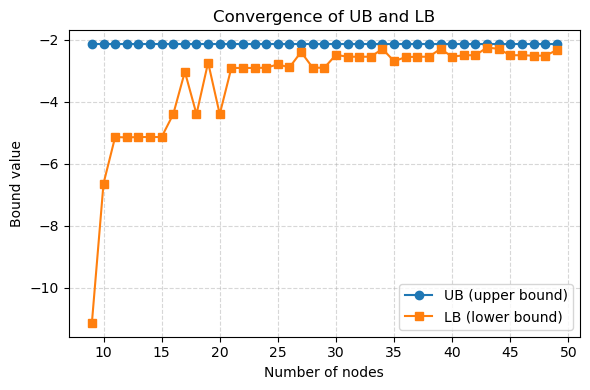

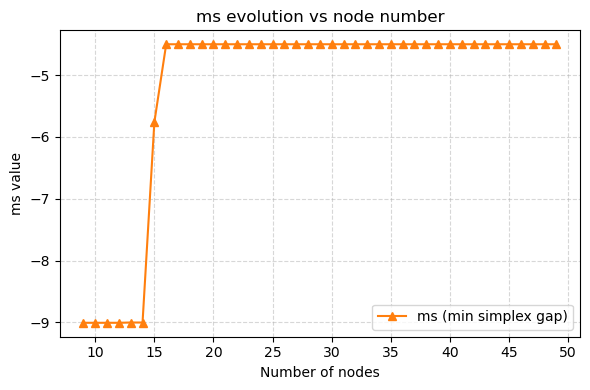

In [7]:
# ===================== Plot convergence history =====================

# 取出数据
nodes = hist["node_count"]
LB = hist["LB_hist"]
UB = hist["UB_hist"]
ms = hist["ms_hist"]

# -------- 图1: UB & LB vs node number --------
plt.figure(figsize=(6,4))
plt.plot(nodes[1:], UB[1:], marker='o', label='UB (upper bound)')
plt.plot(nodes[1:], LB[1:], marker='s', label='LB (lower bound)')
plt.xlabel("Number of nodes")
plt.ylabel("Bound value")
plt.title("Convergence of UB and LB")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# -------- 图2: ms vs node number --------
plt.figure(figsize=(6,4))
plt.plot(nodes[1:], ms[1:], marker='^', color='tab:orange', label='ms (min simplex gap)')
plt.xlabel("Number of nodes")
plt.ylabel("ms value")
plt.title("ms evolution vs node number")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
for msi in ms:
    print(msi)

-15.638806826915822
-9.005037619854605
-9.005037476330925
-9.005037366550937
-9.005037325418535
-9.00063027248549
-9.000630093055118
-5.759732122137686
-4.5000795410808685
-4.500079554784358
-4.500079556516512
-4.500079557193482
-4.500079559060763
-4.5000795590802785
-4.500079556916262
-4.500079558425178
-4.5000795591336225
-4.50007955918492
-4.500079558445728
-4.500079554674544
-4.500079559162183
-4.500079558502378
-4.5000795547120305
-4.500079558510379
-4.500079559185602
-4.5000795590886415
-4.500079561411736
-4.500079559095594
-4.500079559098747
-4.500079558446551
-4.500079558450187
-4.500079559065162
-4.50007955849364
-4.500079557248604
-4.5000795591876965
-4.500079558169741
-4.500079559041087
-4.5000795591838845
-4.500079559179964
-4.5000795590555835
-4.500079559180914
-4.500079557099468
